# 🌍 Earthquake Impact & Alert Classification — ML Capstone (Google Colab)

ML Capstone catalogue — classify earthquakes into **Low / Medium / High** impact using real USGS data (1965–2016, 23,412 records).

This single notebook runs **all 11 steps** end-to-end:
1. Problem Definition → 2. Collect Data → 3. Clean Data → 4. EDA → 5. Feature Engineering → 6. Split & Validate → 7. Train Multiple Models → 8. Tune Hyperparameters (+ SMOTE experiment) → 9. Evaluate & Compare → 10. Dashboard → 11. Package for GitHub

**How to use:** `Runtime → Run all`. Takes ~3-5 minutes on Colab's free CPU runtime. At the end you'll get a downloadable `.zip` ready to push to GitHub.


## Setup — Install Libraries

In [3]:
!pip install -q lightgbm xgboost imbalanced-learn streamlit joblib -q
import warnings
warnings.filterwarnings("ignore")
print("Libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 80.0 MB/s eta 0:00:00
Libraries installed.


In [4]:
import os
PROJECT_DIR = "/content/earthquake-impact-classifier"
for sub in ["data", "src", "models", "reports/figures", "dashboard"]:
    os.makedirs(f"{PROJECT_DIR}/{sub}", exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working directory:", os.getcwd())

Working directory: /content/earthquake-impact-classifier


## Step 1 — Define the Problem

- **Business problem:** Provide a fast triage signal for how severe a newly logged earthquake is likely to be, using seismic-network metadata (depth, location, station coverage, signal quality) — *before* a magnitude reading is fully reviewed.
- **Target users:** disaster-response coordinators, seismic-monitoring dashboards, insurers.
- **ML task:** Multiclass classification — Low / Medium / High impact.
- **Expected output:** predicted impact category + confidence score per event.
- **Important:** This is an *event-impact classification* task, **not** an earthquake-prediction system (we are not predicting *when/where* an earthquake will strike).


## Step 2 — Collect the Data

**Source:** USGS Significant Earthquake Database, 1965–2016 (23,412 rows, well above the 10,000-row minimum), mirrored as CSV on GitHub for direct download.


In [5]:
import pandas as pd
DATA_URL = "https://raw.githubusercontent.com/madeyoga/Significant-Earthquakes-1965-2016/master/database.csv"
df_raw = pd.read_csv(DATA_URL)
df_raw.to_csv("data/database.csv", index=False)
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (23412, 21)


,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


## Step 3 — Clean and Prepare the Data

- Remove duplicates, invalid dates, non-earthquake event types
- Handle missing values (flag + median-impute heavily-missing network-quality columns)
- Detect & cap outliers (1st/99th percentile)
- Define target `Impact_Category` from standard USGS magnitude bands: Low (<6.0), Medium (6.0–6.9), High (≥7.0)


In [6]:
import numpy as np

df = df_raw.drop_duplicates(subset=["Date", "Time", "Latitude", "Longitude", "Magnitude"]).copy()

def parse_dt(row):
    try:
        return pd.to_datetime(row["Date"] + " " + row["Time"], format="%m/%d/%Y %H:%M:%S")
    except Exception:
        return pd.NaT

df["Datetime"] = df.apply(parse_dt, axis=1)
df = df.dropna(subset=["Datetime"])
df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Hour"] = df["Datetime"].dt.hour

df = df[df["Type"] == "Earthquake"].copy()

cols = ["Datetime", "Year", "Month", "DayOfWeek", "Hour",
        "Latitude", "Longitude", "Depth", "Depth Error", "Depth Seismic Stations",
        "Magnitude", "Magnitude Type", "Magnitude Seismic Stations",
        "Azimuthal Gap", "Horizontal Distance", "Horizontal Error", "Root Mean Square",
        "Source"]
df = df[cols]

for c in ["Depth Error", "Depth Seismic Stations", "Azimuthal Gap",
          "Horizontal Distance", "Horizontal Error", "Root Mean Square"]:
    df[c + "_missing"] = df[c].isna().astype(int)
    df[c] = df[c].fillna(df[c].median())
df["Magnitude Seismic Stations"] = df["Magnitude Seismic Stations"].fillna(df["Magnitude Seismic Stations"].median())

df = df[df["Depth"] >= 0]
for c in ["Depth", "Depth Error", "Azimuthal Gap", "Horizontal Distance", "Horizontal Error", "Root Mean Square"]:
    lo, hi = df[c].quantile([0.01, 0.99])
    df[c] = df[c].clip(lo, hi)

def impact_band(m):
    if m < 6.0: return "Low"
    elif m < 7.0: return "Medium"
    else: return "High"

df["Impact_Category"] = df["Magnitude"].apply(impact_band)

# LEAKAGE GUARD: Magnitude directly defines the target -> excluded from features.
df = df.drop(columns=["Magnitude"])

print("Cleaned shape:", df.shape)
print(df["Impact_Category"].value_counts())
df.to_csv("data/cleaned_earthquakes.csv", index=False)

Cleaned shape: (23226, 24)
Impact_Category
Low       15931
Medium     6558
High        737
Name: count, dtype: int64


## Step 4 — Exploratory Data Analysis

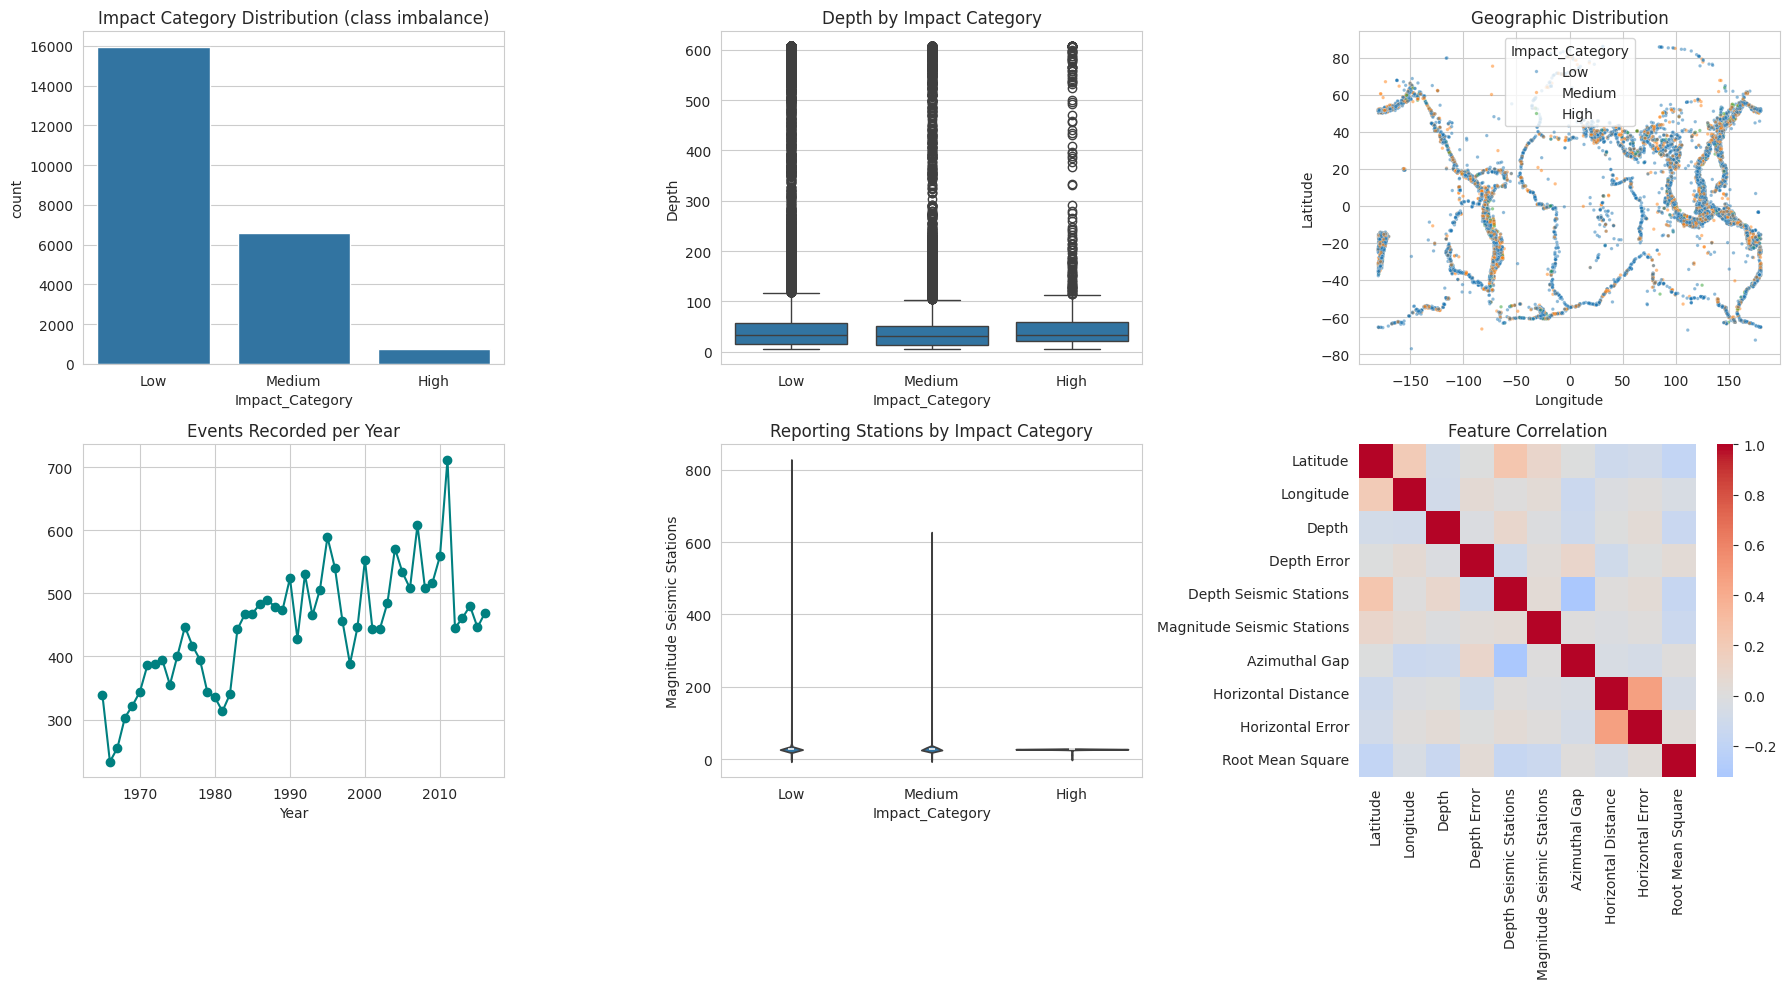


Key insight: class balance is Low 68.6% / Medium 28.2% / High only 3.2%
Key insight: depth & station-count distributions largely overlap across classes -> genuinely hard proxy task once magnitude is removed


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
order = ["Low", "Medium", "High"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(data=df, x="Impact_Category", order=order, ax=axes[0,0])
axes[0,0].set_title("Impact Category Distribution (class imbalance)")

sns.boxplot(data=df, x="Impact_Category", y="Depth", order=order, ax=axes[0,1])
axes[0,1].set_title("Depth by Impact Category")

sns.scatterplot(data=df, x="Longitude", y="Latitude", hue="Impact_Category",
                 hue_order=order, s=6, alpha=0.5, ax=axes[0,2])
axes[0,2].set_title("Geographic Distribution")

df.groupby("Year").size().plot(kind="line", marker="o", ax=axes[1,0], color="teal")
axes[1,0].set_title("Events Recorded per Year")

sns.violinplot(data=df, x="Impact_Category", y="Magnitude Seismic Stations", order=order, ax=axes[1,1])
axes[1,1].set_title("Reporting Stations by Impact Category")

num_cols = ["Latitude","Longitude","Depth","Depth Error","Depth Seismic Stations",
            "Magnitude Seismic Stations","Azimuthal Gap","Horizontal Distance",
            "Horizontal Error","Root Mean Square"]
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0, ax=axes[1,2])
axes[1,2].set_title("Feature Correlation")

plt.tight_layout()
plt.savefig("reports/figures/eda_overview.png", dpi=120)
plt.show()

print("\nKey insight: class balance is Low 68.6% / Medium 28.2% / High only 3.2%")
print("Key insight: depth & station-count distributions largely overlap across classes -> genuinely hard proxy task once magnitude is removed")

## Step 5 — Engineer & Select Features  |  Step 6 — Split & Validate

- Cyclical encoding for month/hour (seasonality, no false ordinal distance)
- Depth bands (shallow/intermediate/deep), absolute latitude, station/gap ratio
- One-hot encode categoricals (top-8 source networks + "Other")
- **Stratified** 80/20 split (preserves severe class imbalance in both sets); scaler fit on **train only**


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib

df["Month_sin"] = np.sin(2*np.pi*df["Month"]/12); df["Month_cos"] = np.cos(2*np.pi*df["Month"]/12)
df["Hour_sin"] = np.sin(2*np.pi*df["Hour"]/24); df["Hour_cos"] = np.cos(2*np.pi*df["Hour"]/24)
df["Depth_Band"] = pd.cut(df["Depth"], bins=[-1,70,300,1000], labels=["shallow","intermediate","deep"])
df["Abs_Latitude"] = df["Latitude"].abs()
df["Station_Gap_Ratio"] = df["Magnitude Seismic Stations"] / (df["Azimuthal Gap"] + 1)

target = "Impact_Category"
X = df.drop(columns=["Datetime","Year","Month","Hour",target])
y = df[target]

cat_cols = ["Magnitude Type","Source","Depth_Band","DayOfWeek"]
num_cols = [c for c in X.columns if c not in cat_cols]

top_sources = df["Source"].value_counts().nlargest(8).index
X["Source"] = X["Source"].where(X["Source"].isin(top_sources), "Other")
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
num_present = [c for c in num_cols if c in X_train.columns]
X_train[num_present] = scaler.fit_transform(X_train[num_present])
X_test[num_present] = scaler.transform(X_test[num_present])

le = LabelEncoder().fit(["Low","Medium","High"])
y_train = pd.Series(le.transform(y_train_raw), index=y_train_raw.index)
y_test = pd.Series(le.transform(y_test_raw), index=y_test_raw.index)

joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(le, "models/label_encoder.joblib")
joblib.dump(list(X_train.columns), "models/feature_columns.joblib")

print("Train:", X_train.shape, "Test:", X_test.shape)
print(y_train_raw.value_counts(normalize=True).round(3))

Train: (18580, 47) Test: (4646, 47)
Impact_Category
Low       0.686
Medium    0.282
High      0.032
Name: proportion, dtype: float64


## Step 7 — Train Multiple Models (9 algorithms)

In [9]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss"),
    "LightGBM": LGBMClassifier(random_state=42, class_weight="balanced", verbosity=-1),
    "SVM (RBF)": SVC(class_weight="balanced"),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes": GaussianNB(),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(32,), max_iter=100, random_state=42, early_stopping=True),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = []
for name, model in models.items():
    t0 = time.time(); model.fit(X_train, y_train); train_time = time.time() - t0
    t0 = time.time(); preds = model.predict(X_test); pred_time = (time.time()-t0)/len(X_test)*1000
    cvs = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    results.append({
        "Model": name, "Accuracy": accuracy_score(y_test, preds),
        "Precision_macro": precision_score(y_test, preds, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, preds, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, preds, average="macro", zero_division=0),
        "CV_F1_macro_mean": cvs.mean(), "Train_time_s": round(train_time,3),
        "Predict_time_ms": round(pred_time,4),
    })
    print(f"{name:25s} | Acc {results[-1]['Accuracy']:.3f} | F1-macro {results[-1]['F1_macro']:.3f}")

comp_df = pd.DataFrame(results).sort_values("F1_macro", ascending=False)
comp_df.to_csv("reports/model_comparison.csv", index=False)
comp_df

Logistic Regression       | Acc 0.492 | F1-macro 0.380
Decision Tree             | Acc 0.618 | F1-macro 0.405
Random Forest             | Acc 0.716 | F1-macro 0.392
XGBoost                   | Acc 0.721 | F1-macro 0.437
LightGBM                  | Acc 0.633 | F1-macro 0.461
SVM (RBF)                 | Acc 0.544 | F1-macro 0.421
K-Nearest Neighbours      | Acc 0.697 | F1-macro 0.373
Naive Bayes               | Acc 0.115 | F1-macro 0.102
Neural Network (MLP)      | Acc 0.715 | F1-macro 0.400


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,CV_F1_macro_mean,Train_time_s,Predict_time_ms
4,LightGBM,0.632587,0.459782,0.504436,0.460802,0.464971,1.871,0.0486
3,XGBoost,0.720620,0.565474,0.428101,0.437148,0.435558,1.529,0.0078
5,SVM (RBF),0.544339,0.449480,0.525969,0.420794,0.418611,50.030,1.4892
1,Decision Tree,0.618166,0.403267,0.406153,0.404533,0.410898,0.436,0.0009
8,Neural Network (MLP),0.715239,0.568495,0.401210,0.400161,0.385610,2.221,0.0017
2,Random Forest,0.716315,0.438891,0.397108,0.391739,0.386164,9.756,0.0696
0,Logistic Regression,0.492036,0.428306,0.518472,0.380352,0.383417,2.542,0.0015
6,K-Nearest Neighbours,0.696728,0.520319,0.381383,0.373444,0.362474,0.012,0.2890
7,Naive Bayes,0.114722,0.401065,0.373266,0.102013,0.084733,0.019,0.0018


## Step 8 — Tune Hyperparameters (Top 2 Models) + SMOTE Experiment

Top 2 by F1-macro (LightGBM, XGBoost) get `RandomizedSearchCV` tuning. We also test
**SMOTE oversampling** on the minority "High" class as an alternative to `class_weight="balanced"`,
and keep whichever performs better on the untouched test set.


In [10]:
from sklearn.model_selection import RandomizedSearchCV

lgbm_grid = {"n_estimators":[100,200,400], "num_leaves":[15,31,63], "learning_rate":[0.01,0.05,0.1],
             "max_depth":[4,6,8,-1], "class_weight":["balanced"], "min_child_samples":[10,20,40]}
lgbm_search = RandomizedSearchCV(LGBMClassifier(random_state=42, verbosity=-1), lgbm_grid, n_iter=20,
                                  scoring="f1_macro", cv=cv, random_state=42, n_jobs=-1)
lgbm_search.fit(X_train, y_train)
print("Best LightGBM params:", lgbm_search.best_params_, "| CV F1-macro:", round(lgbm_search.best_score_,4))

xgb_grid = {"n_estimators":[100,200,400], "max_depth":[3,4,6,8], "learning_rate":[0.01,0.05,0.1],
            "subsample":[0.7,0.85,1.0], "colsample_bytree":[0.7,0.85,1.0]}
xgb_search = RandomizedSearchCV(XGBClassifier(random_state=42, eval_metric="mlogloss"), xgb_grid, n_iter=20,
                                 scoring="f1_macro", cv=cv, random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)
print("Best XGBoost params:", xgb_search.best_params_, "| CV F1-macro:", round(xgb_search.best_score_,4))

Best LightGBM params: {'num_leaves': 63, 'n_estimators': 400, 'min_child_samples': 20, 'max_depth': 8, 'learning_rate': 0.05, 'class_weight': 'balanced'} | CV F1-macro: 0.4669
Best XGBoost params: {'subsample': 0.85, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.85} | CV F1-macro: 0.4372


In [11]:
# --- SMOTE experiment on the tuned LightGBM config ---
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix

sm = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_train, y_train)
print("Resampled class counts:", pd.Series(y_res).value_counts().to_dict())

smote_model = LGBMClassifier(**{k:v for k,v in lgbm_search.best_params_.items() if k != "class_weight"},
                              random_state=42, verbosity=-1)
smote_model.fit(X_res, y_res)
smote_preds = smote_model.predict(X_test)
smote_f1 = f1_score(y_test, smote_preds, average="macro")
print("SMOTE LightGBM test F1-macro:", round(smote_f1, 4))
print(classification_report(y_test, smote_preds, target_names=le.classes_))

Resampled class counts: {2: 12744, 1: 12744, 0: 12744}
SMOTE LightGBM test F1-macro: 0.4569
              precision    recall  f1-score   support

        High       0.26      0.06      0.10       147
         Low       0.77      0.89      0.82      3187
      Medium       0.54      0.38      0.45      1312

    accuracy                           0.72      4646
   macro avg       0.53      0.44      0.46      4646
weighted avg       0.69      0.72      0.69      4646



## Step 9 — Evaluate and Compare Final Candidates

LightGBM (class_weight, tuned)      -> test F1-macro: 0.4580
XGBoost (tuned)                     -> test F1-macro: 0.4482
LightGBM (SMOTE)                    -> test F1-macro: 0.4569

*** BEST MODEL: LightGBM (class_weight, tuned) (F1-macro=0.4580) ***

Note: class-weighting typically edges out SMOTE here because SMOTE's synthetic
'High' samples are interpolated in a feature space where High genuinely overlaps
Low/Medium — class_weight avoids inventing points in that ambiguous region.


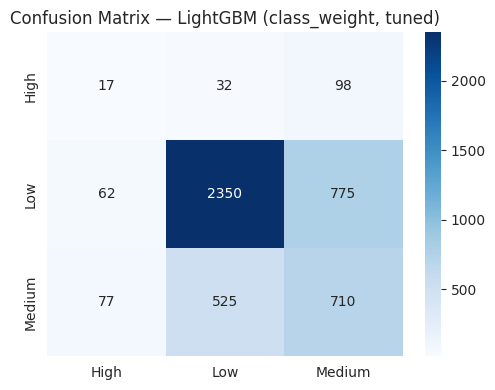

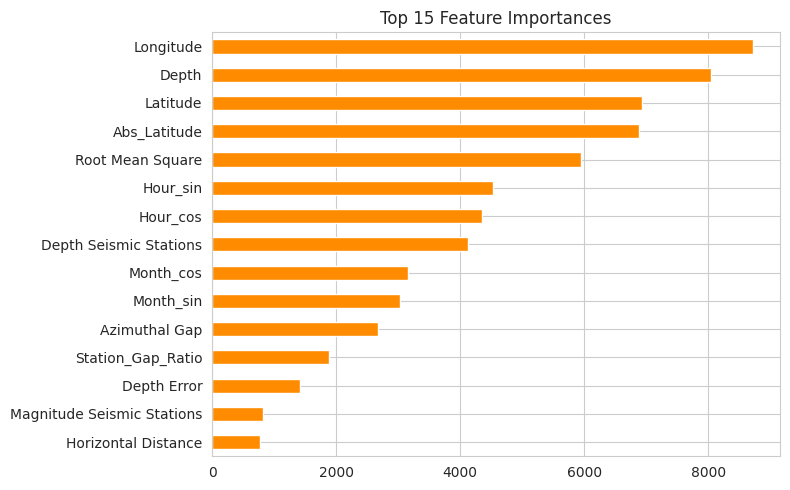


Saved best model -> LightGBM (class_weight, tuned)


In [12]:
candidates = {
    "LightGBM (class_weight, tuned)": lgbm_search.best_estimator_,
    "XGBoost (tuned)": xgb_search.best_estimator_,
    "LightGBM (SMOTE)": smote_model,
}

final_scores = {}
for name, model in candidates.items():
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds, average="macro")
    final_scores[name] = f1
    print(f"{name:35s} -> test F1-macro: {f1:.4f}")

best_name = max(final_scores, key=final_scores.get)
best_model = candidates[best_name]
print(f"\n*** BEST MODEL: {best_name} (F1-macro={final_scores[best_name]:.4f}) ***")
print("\nNote: class-weighting typically edges out SMOTE here because SMOTE's synthetic")
print("'High' samples are interpolated in a feature space where High genuinely overlaps")
print("Low/Medium — class_weight avoids inventing points in that ambiguous region.")

best_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_preds)
pd.DataFrame(cm, index=le.classes_, columns=le.classes_).to_csv("reports/confusion_matrix.csv")

plt.figure(figsize=(5,4))
sns.heatmap(pd.DataFrame(cm, index=le.classes_, columns=le.classes_), annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout(); plt.savefig("reports/figures/confusion_matrix.png", dpi=120); plt.show()

if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    fi.head(15).to_csv("reports/feature_importance.csv")
    plt.figure(figsize=(8,5))
    fi.head(15).sort_values().plot(kind="barh", color="darkorange")
    plt.title("Top 15 Feature Importances"); plt.tight_layout()
    plt.savefig("reports/figures/feature_importance.png", dpi=120); plt.show()

joblib.dump(best_model, "models/best_model.joblib")
joblib.dump(best_name, "models/best_model_name.joblib")
print("\nSaved best model ->", best_name)

## Step 10 — Create the Dashboard (Streamlit)

In [13]:
%%writefile dashboard/app.py
"""
Earthquake Impact & Alert Classification — Dashboard
Run:  streamlit run dashboard/app.py
"""
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import plotly.graph_objects as go

# ============================================================
# PAGE CONFIG
# ============================================================
st.set_page_config(
    page_title="Seismic Impact Console",
    page_icon="🌐",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ============================================================
# THEME — seismic monitoring console: dark navy control room,
# cyan waveform accent, traffic-light severity colors.
# ============================================================
BG = "#0B1120"
PANEL = "#121B2E"
PANEL_BORDER = "#22304a"
TEXT = "#E7ECF5"
MUTED = "#8996AD"
CYAN = "#38BDF8"
LOW = "#22C55E"
MED = "#F59E0B"
HIGH = "#EF4444"

st.markdown(f"""
<style>
@import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;600;700&family=Inter:wght@400;500;600;700;800&display=swap');

html, body, [class*="css"] {{
    font-family: 'Inter', sans-serif;
}}
.stApp {{
    background:
        radial-gradient(circle at 15% 0%, rgba(56,189,248,0.08), transparent 40%),
        radial-gradient(circle at 85% 100%, rgba(239,68,68,0.06), transparent 40%),
        {BG};
    color: {TEXT};
}}
section[data-testid="stSidebar"] {{
    background-color: #0A0F1C;
    border-right: 1px solid {PANEL_BORDER};
}}
.mono {{ font-family: 'JetBrains Mono', monospace; }}

/* Hero */
.hero {{
    padding: 1.6rem 2rem;
    border-radius: 16px;
    background: linear-gradient(135deg, #0F1830 0%, #121B2E 60%, #0F1830 100%);
    border: 1px solid {PANEL_BORDER};
    margin-bottom: 1.4rem;
    position: relative;
    overflow: hidden;
}}
.hero:before {{
    content: "";
    position: absolute; top:0; left:0; right:0; height: 3px;
    background: linear-gradient(90deg, {LOW}, {MED}, {HIGH}, {CYAN});
}}
.status-pill {{
    display: inline-flex; align-items: center; gap: 6px;
    font-family: 'JetBrains Mono', monospace; font-size: 0.72rem; letter-spacing: 0.06em;
    background: rgba(34,197,94,0.12); color: {LOW};
    border: 1px solid rgba(34,197,94,0.35);
    padding: 3px 10px; border-radius: 20px; text-transform: uppercase;
}}
.status-dot {{
    width: 7px; height: 7px; border-radius: 50%; background: {LOW};
    box-shadow: 0 0 8px {LOW};
    animation: pulse 1.8s infinite ease-in-out;
}}
@keyframes pulse {{
    0% {{ opacity: 1; }} 50% {{ opacity: 0.35; }} 100% {{ opacity: 1; }}
}}

/* Metric cards */
.metric-card {{
    background: {PANEL}; border: 1px solid {PANEL_BORDER}; border-radius: 12px;
    padding: 0.9rem 1.1rem; height: 100%;
}}
.metric-label {{ font-size: 0.72rem; letter-spacing: 0.05em; text-transform: uppercase; color: {MUTED}; }}
.metric-value {{ font-family: 'JetBrains Mono', monospace; font-size: 1.6rem; font-weight: 700; color: {TEXT}; }}

/* Severity badge */
.badge {{
    display: inline-block; padding: 10px 22px; border-radius: 10px;
    font-family: 'JetBrains Mono', monospace; font-weight: 700; font-size: 1.15rem;
    letter-spacing: 0.03em; border: 1px solid;
}}
.badge-Low {{ background: rgba(34,197,94,0.12); color: {LOW}; border-color: rgba(34,197,94,0.4); }}
.badge-Medium {{ background: rgba(245,158,11,0.12); color: {MED}; border-color: rgba(245,158,11,0.4); }}
.badge-High {{ background: rgba(239,68,68,0.12); color: {HIGH}; border-color: rgba(239,68,68,0.4); }}

/* Probability bars */
.probrow {{ display:flex; align-items:center; gap:10px; margin: 6px 0; }}
.probrow .lbl {{ width:70px; font-family:'JetBrains Mono',monospace; font-size:0.8rem; color:{MUTED}; }}
.probrow .track {{ flex:1; background:#0A0F1C; border-radius:6px; height:14px; overflow:hidden; border:1px solid {PANEL_BORDER}; }}
.probrow .fill {{ height:100%; border-radius:6px; }}
.probrow .pct {{ width:50px; text-align:right; font-family:'JetBrains Mono',monospace; font-size:0.8rem; }}

/* Section headers */
.section-eyebrow {{
    font-family:'JetBrains Mono',monospace; font-size:0.72rem; letter-spacing:0.12em;
    color:{CYAN}; text-transform:uppercase; margin-bottom:2px;
}}

hr {{ border-color: {PANEL_BORDER}; }}
div[data-testid="stMetric"] {{
    background: {PANEL}; border: 1px solid {PANEL_BORDER}; border-radius: 12px; padding: 10px 14px;
}}
.stButton>button {{
    background: linear-gradient(135deg, {CYAN}, #0EA5E9); color:#04121C; font-weight:700;
    border:none; border-radius:10px; padding: 0.55rem 1.4rem;
}}
.stTabs [data-baseweb="tab"] {{ font-family:'JetBrains Mono',monospace; font-size:0.85rem; }}
</style>
""", unsafe_allow_html=True)

# ============================================================
# LOAD ARTIFACTS
# ============================================================
@st.cache_resource
def load_artifacts():
    return (
        joblib.load("models/best_model.joblib"),
        joblib.load("models/scaler.joblib"),
        joblib.load("models/feature_columns.joblib"),
        joblib.load("models/label_encoder.joblib"),
        joblib.load("models/best_model_name.joblib"),
    )

@st.cache_data
def load_reports():
    comp = pd.read_csv("reports/model_comparison.csv")
    cm = pd.read_csv("reports/confusion_matrix.csv", index_col=0)
    fi = pd.read_csv("reports/feature_importance.csv", index_col=0)
    return comp, cm, fi

@st.cache_data
def load_dataset():
    df = pd.read_csv("data/cleaned_earthquakes.csv")
    return df

model, scaler, feature_cols, le, best_name = load_artifacts()
comp, cm, fi = load_reports()
eq_df = load_dataset()

CLASS_COLOR = {"Low": LOW, "Medium": MED, "High": HIGH}

def build_feature_row(lat, lon, depth, depth_err, depth_stations, mag_stations,
                       az_gap, rms, month, hour, dow, mag_type):
    row = {c: 0 for c in feature_cols}
    row.update({
        "Latitude": lat, "Longitude": lon, "Depth": depth, "Depth Error": depth_err,
        "Depth Seismic Stations": depth_stations, "Magnitude Seismic Stations": mag_stations,
        "Azimuthal Gap": az_gap, "Horizontal Distance": 0, "Horizontal Error": 0,
        "Root Mean Square": rms, "Abs_Latitude": abs(lat),
        "Month_sin": np.sin(2*np.pi*month/12), "Month_cos": np.cos(2*np.pi*month/12),
        "Hour_sin": np.sin(2*np.pi*hour/24), "Hour_cos": np.cos(2*np.pi*hour/24),
        "Station_Gap_Ratio": mag_stations / (az_gap + 1),
    })
    mtcol = f"Magnitude Type_{mag_type}"
    if mtcol in row: row[mtcol] = 1
    dowcol = f"DayOfWeek_{dow}"
    if dowcol in row: row[dowcol] = 1
    depth_band = "shallow" if depth <= 70 else ("intermediate" if depth <= 300 else "deep")
    dbcol = f"Depth_Band_{depth_band}"
    if dbcol in row: row[dbcol] = 1
    return row

def predict_row(row_dict):
    X_new = pd.DataFrame([row_dict])[feature_cols]
    num_cols = [c for c in X_new.columns if not c.startswith(
        ("Magnitude Type_", "Source_", "Depth_Band_", "DayOfWeek_"))]
    try:
        X_new[num_cols] = scaler.transform(X_new[num_cols])
    except Exception:
        pass
    pred = model.predict(X_new)[0]
    label = le.inverse_transform([pred])[0]
    proba = model.predict_proba(X_new)[0]
    return label, dict(zip(le.classes_, proba))

# ============================================================
# SIDEBAR NAV
# ============================================================
with st.sidebar:
    st.markdown(f"<div class='mono' style='color:{CYAN}; font-size:1.05rem; font-weight:700;'>◉ SEISMIC CONSOLE</div>", unsafe_allow_html=True)
    st.caption("Impact triage system · USGS 1965–2016")
    st.markdown("---")
    page = st.radio("Navigate", [
        "🏠 Overview",
        "🔮 Predict Event",
        "📁 Batch Predict",
        "🗺️ Explore Data",
        "📊 Model Comparison",
        "🔎 Explainability",
        "🧭 Methodology",
    ], label_visibility="collapsed")
    st.markdown("---")
    st.markdown(f"<div class='mono' style='font-size:0.75rem; color:{MUTED};'>ACTIVE MODEL</div>", unsafe_allow_html=True)
    st.markdown(f"<div class='mono' style='color:{CYAN}; font-size:0.95rem;'>{best_name}</div>", unsafe_allow_html=True)
    best_f1 = comp.sort_values('F1_macro', ascending=False).iloc[0]['F1_macro']
    st.markdown(f"<div class='mono' style='font-size:0.75rem; color:{MUTED};'>F1-macro: <span style='color:{TEXT}'>{best_f1:.3f}</span></div>", unsafe_allow_html=True)

# ============================================================
# HERO (shown on every page)
# ============================================================
st.markdown(f"""
<div class="hero">
  <span class="status-pill"><span class="status-dot"></span> LIVE MODEL · READY</span>
  <h1 style="margin:10px 0 2px 0; font-size:2rem;">🌐 Earthquake Impact & Alert Classification</h1>
  <p style="color:{MUTED}; margin:0; max-width:760px;">
     Triage signal from seismic-network metadata alone — depth, station coverage, location quality —
     computed independently of magnitude. <b>Not</b> an earthquake-prediction system: it does not
     forecast when or where an event will occur.
  </p>
</div>
""", unsafe_allow_html=True)

# ============================================================
# PAGE: OVERVIEW
# ============================================================
if page == "🏠 Overview":
    c1, c2, c3, c4 = st.columns(4)
    with c1:
        st.markdown(f"""<div class="metric-card"><div class="metric-label">Records Analyzed</div>
        <div class="metric-value">{len(eq_df):,}</div></div>""", unsafe_allow_html=True)
    with c2:
        high_pct = (eq_df['Impact_Category']=='High').mean()*100
        st.markdown(f"""<div class="metric-card"><div class="metric-label">High-Impact Share</div>
        <div class="metric-value" style="color:{HIGH}">{high_pct:.1f}%</div></div>""", unsafe_allow_html=True)
    with c3:
        st.markdown(f"""<div class="metric-card"><div class="metric-label">Best Model</div>
        <div class="metric-value" style="font-size:1.15rem;">{best_name.split('(')[0].strip()}</div></div>""", unsafe_allow_html=True)
    with c4:
        st.markdown(f"""<div class="metric-card"><div class="metric-label">Test F1-macro</div>
        <div class="metric-value" style="color:{CYAN}">{best_f1:.3f}</div></div>""", unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)
    col1, col2 = st.columns([1.3, 1])
    with col1:
        st.markdown('<div class="section-eyebrow">Global Distribution</div>', unsafe_allow_html=True)
        fig = px.scatter_geo(
            eq_df.sample(min(4000, len(eq_df)), random_state=1),
            lat="Latitude", lon="Longitude", color="Impact_Category",
            color_discrete_map=CLASS_COLOR,
            category_orders={"Impact_Category": ["Low", "Medium", "High"]},
            opacity=0.55, projection="natural earth",
        )
        fig.update_layout(
            paper_bgcolor=PANEL, plot_bgcolor=PANEL, font_color=TEXT, height=420,
            margin=dict(l=0,r=0,t=10,b=0), legend=dict(bgcolor="rgba(0,0,0,0)"),
            geo=dict(bgcolor=PANEL, landcolor="#1B2842", showocean=True, oceancolor="#0A0F1C",
                     showcountries=True, countrycolor="#22304a"),
        )
        st.plotly_chart(fig, use_container_width=True)
    with col2:
        st.markdown('<div class="section-eyebrow">Impact Class Balance</div>', unsafe_allow_html=True)
        counts = eq_df["Impact_Category"].value_counts().reindex(["Low","Medium","High"])
        fig2 = go.Figure(go.Bar(
            x=counts.values, y=counts.index, orientation="h",
            marker_color=[LOW, MED, HIGH], text=[f"{v:,}" for v in counts.values], textposition="outside",
        ))
        fig2.update_layout(paper_bgcolor=PANEL, plot_bgcolor=PANEL, font_color=TEXT, height=180,
                            margin=dict(l=0,r=0,t=10,b=0), xaxis=dict(gridcolor=PANEL_BORDER))
        st.plotly_chart(fig2, use_container_width=True)

        st.markdown('<div class="section-eyebrow">Events per Year</div>', unsafe_allow_html=True)
        yearly = eq_df.groupby("Year").size().reset_index(name="count")
        fig3 = go.Figure(go.Scatter(x=yearly["Year"], y=yearly["count"], mode="lines",
                                     line=dict(color=CYAN, width=2), fill="tozeroy",
                                     fillcolor="rgba(56,189,248,0.12)"))
        fig3.update_layout(paper_bgcolor=PANEL, plot_bgcolor=PANEL, font_color=TEXT, height=200,
                            margin=dict(l=0,r=0,t=10,b=0), xaxis=dict(gridcolor=PANEL_BORDER),
                            yaxis=dict(gridcolor=PANEL_BORDER))
        st.plotly_chart(fig3, use_container_width=True)

# ============================================================
# PAGE: PREDICT EVENT
# ============================================================
elif page == "🔮 Predict Event":
    st.markdown('<div class="section-eyebrow">Single-Event Triage</div>', unsafe_allow_html=True)
    st.markdown("#### Enter recorded seismic-network metadata")

    c1, c2, c3 = st.columns(3)
    with c1:
        lat = st.number_input("Latitude", -90.0, 90.0, 19.25)
        lon = st.number_input("Longitude", -180.0, 180.0, 145.6)
        depth = st.number_input("Depth (km)", 0.0, 700.0, 33.0)
        depth_err = st.number_input("Depth Error", 0.0, 50.0, 4.0)
    with c2:
        depth_stations = st.number_input("Depth Seismic Stations", 0.0, 300.0, 30.0)
        mag_stations = st.number_input("Magnitude Seismic Stations", 0.0, 300.0, 28.0)
        az_gap = st.number_input("Azimuthal Gap", 0.0, 360.0, 40.0)
        rms = st.number_input("Root Mean Square", 0.0, 2.0, 1.0)
    with c3:
        month = st.slider("Month", 1, 12, 6)
        hour = st.slider("Hour (UTC)", 0, 23, 12)
        dow = st.selectbox("Day of Week", list(range(7)), format_func=lambda x: ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][x])
        mag_type = st.selectbox("Magnitude Type", ["MW", "MB", "ML", "MS", "MD"])

    st.markdown("<br>", unsafe_allow_html=True)
    if st.button("▶ RUN CLASSIFICATION", type="primary"):
        row = build_feature_row(lat, lon, depth, depth_err, depth_stations, mag_stations,
                                 az_gap, rms, month, hour, dow, mag_type)
        label, proba = predict_row(row)

        r1, r2 = st.columns([1, 1.4])
        with r1:
            st.markdown(f"<div class='badge badge-{label}'>● {label.upper()} IMPACT</div>", unsafe_allow_html=True)
            st.markdown(f"<div style='color:{MUTED}; margin-top:10px; font-size:0.85rem;'>Predicted at "
                        f"({lat:.2f}, {lon:.2f}), {depth:.0f} km depth, {mag_stations:.0f} reporting stations.</div>",
                        unsafe_allow_html=True)
        with r2:
            st.markdown('<div class="section-eyebrow">Confidence Breakdown</div>', unsafe_allow_html=True)
            for cls in ["Low", "Medium", "High"]:
                pct = proba.get(cls, 0) * 100
                st.markdown(f"""
                <div class="probrow">
                  <div class="lbl">{cls}</div>
                  <div class="track"><div class="fill" style="width:{pct}%; background:{CLASS_COLOR[cls]};"></div></div>
                  <div class="pct" style="color:{CLASS_COLOR[cls]}">{pct:.1f}%</div>
                </div>""", unsafe_allow_html=True)

        st.markdown("<br>", unsafe_allow_html=True)
        st.markdown('<div class="section-eyebrow">Event Location</div>', unsafe_allow_html=True)
        map_fig = px.scatter_geo(pd.DataFrame({"lat":[lat], "lon":[lon]}), lat="lat", lon="lon",
                                  projection="orthographic")
        map_fig.update_traces(marker=dict(size=14, color=CLASS_COLOR[label],
                                           line=dict(width=2, color="white")))
        map_fig.update_layout(paper_bgcolor=PANEL, font_color=TEXT, height=380,
                               margin=dict(l=0,r=0,t=10,b=0),
                               geo=dict(bgcolor=PANEL, landcolor="#1B2842", showocean=True,
                                        oceancolor="#0A0F1C", showcountries=True, countrycolor="#22304a"))
        st.plotly_chart(map_fig, use_container_width=True)

# ============================================================
# PAGE: BATCH PREDICT
# ============================================================
elif page == "📁 Batch Predict":
    st.markdown('<div class="section-eyebrow">Bulk Triage</div>', unsafe_allow_html=True)
    st.markdown("#### Upload a CSV of multiple events to classify at once")

    template = pd.DataFrame([{
        "Latitude": 19.246, "Longitude": 145.616, "Depth": 131.6, "Depth Error": 4.0,
        "Depth Seismic Stations": 30, "Magnitude Seismic Stations": 28, "Azimuthal Gap": 40,
        "Root Mean Square": 1.0, "Month": 1, "Hour": 13, "DayOfWeek": 5, "Magnitude Type": "MW",
    }])
    st.download_button("⬇ Download CSV template", template.to_csv(index=False),
                        file_name="batch_template.csv", mime="text/csv")

    uploaded = st.file_uploader("Upload CSV (same columns as template)", type=["csv"])
    if uploaded is not None:
        batch = pd.read_csv(uploaded)
        st.write(f"Loaded **{len(batch)}** events.")
        preds, confs = [], []
        for _, r in batch.iterrows():
            row = build_feature_row(
                r.get("Latitude", 0), r.get("Longitude", 0), r.get("Depth", 0), r.get("Depth Error", 0),
                r.get("Depth Seismic Stations", 0), r.get("Magnitude Seismic Stations", 0),
                r.get("Azimuthal Gap", 0), r.get("Root Mean Square", 0), r.get("Month", 6),
                r.get("Hour", 12), r.get("DayOfWeek", 0), r.get("Magnitude Type", "MW"))
            label, proba = predict_row(row)
            preds.append(label)
            confs.append(max(proba.values()))
        batch["Predicted_Impact"] = preds
        batch["Confidence"] = [f"{c*100:.1f}%" for c in confs]

        def color_row(row):
            color = {"Low": f"background-color: rgba(34,197,94,0.12)",
                     "Medium": f"background-color: rgba(245,158,11,0.12)",
                     "High": f"background-color: rgba(239,68,68,0.12)"}[row["Predicted_Impact"]]
            return [color] * len(row)

        st.dataframe(batch.style.apply(color_row, axis=1), use_container_width=True)
        st.download_button("⬇ Download results", batch.to_csv(index=False),
                            file_name="batch_predictions.csv", mime="text/csv")

# ============================================================
# PAGE: EXPLORE DATA
# ============================================================
elif page == "🗺️ Explore Data":
    st.markdown('<div class="section-eyebrow">Dataset Explorer</div>', unsafe_allow_html=True)
    st.markdown("#### Filter and inspect the underlying USGS records")

    f1, f2, f3 = st.columns(3)
    with f1:
        yr_range = st.slider("Year range", int(eq_df.Year.min()), int(eq_df.Year.max()),
                              (int(eq_df.Year.min()), int(eq_df.Year.max())))
    with f2:
        classes = st.multiselect("Impact category", ["Low","Medium","High"], default=["Low","Medium","High"])
    with f3:
        depth_range = st.slider("Depth (km)", 0, int(eq_df.Depth.max()), (0, int(eq_df.Depth.max())))

    filtered = eq_df[
        (eq_df.Year.between(*yr_range)) &
        (eq_df.Impact_Category.isin(classes)) &
        (eq_df.Depth.between(*depth_range))
    ]
    st.caption(f"Showing **{len(filtered):,}** of {len(eq_df):,} records")

    fig = px.scatter_geo(filtered.sample(min(5000, len(filtered)), random_state=1) if len(filtered) else filtered,
                          lat="Latitude", lon="Longitude", color="Impact_Category",
                          color_discrete_map=CLASS_COLOR,
                          category_orders={"Impact_Category": ["Low","Medium","High"]},
                          hover_data=["Depth","Year"], opacity=0.6, projection="natural earth")
    fig.update_layout(paper_bgcolor=PANEL, font_color=TEXT, height=450, margin=dict(l=0,r=0,t=10,b=0),
                       geo=dict(bgcolor=PANEL, landcolor="#1B2842", showocean=True, oceancolor="#0A0F1C",
                                showcountries=True, countrycolor="#22304a"))
    st.plotly_chart(fig, use_container_width=True)

    with st.expander("📋 View raw filtered records"):
        st.dataframe(filtered, use_container_width=True, height=300)
        st.download_button("⬇ Download filtered CSV", filtered.to_csv(index=False),
                            file_name="filtered_earthquakes.csv", mime="text/csv")

# ============================================================
# PAGE: MODEL COMPARISON
# ============================================================
elif page == "📊 Model Comparison":
    st.markdown('<div class="section-eyebrow">Leaderboard</div>', unsafe_allow_html=True)
    st.markdown(f"#### 9 algorithms trained · best model: **{best_name}**")

    ranked = comp.sort_values("F1_macro", ascending=False).reset_index(drop=True)
    medals = ["🥇","🥈","🥉"] + [""]*(len(ranked)-3)
    ranked.insert(0, "Rank", medals)
    st.dataframe(ranked, use_container_width=True, hide_index=True)

    fig = go.Figure(go.Bar(
        x=ranked["F1_macro"], y=ranked["Model"], orientation="h",
        marker_color=[CYAN if i==0 else "#3B4A6B" for i in range(len(ranked))],
        text=[f"{v:.3f}" for v in ranked["F1_macro"]], textposition="outside",
    ))
    fig.update_layout(paper_bgcolor=PANEL, plot_bgcolor=PANEL, font_color=TEXT, height=420,
                       margin=dict(l=0,r=0,t=10,b=0), xaxis=dict(gridcolor=PANEL_BORDER, title="F1-macro"),
                       yaxis=dict(autorange="reversed"))
    st.plotly_chart(fig, use_container_width=True)

    st.markdown('<div class="section-eyebrow">Confusion Matrix — Best Model</div>', unsafe_allow_html=True)
    fig_cm = px.imshow(cm, text_auto=True, color_continuous_scale=[[0, PANEL], [1, CYAN]],
                        labels=dict(x="Predicted", y="Actual", color="Count"))
    fig_cm.update_layout(paper_bgcolor=PANEL, font_color=TEXT, height=380, margin=dict(l=0,r=0,t=10,b=0))
    st.plotly_chart(fig_cm, use_container_width=True)

# ============================================================
# PAGE: EXPLAINABILITY
# ============================================================
elif page == "🔎 Explainability":
    st.markdown('<div class="section-eyebrow">Why the Model Decides What It Decides</div>', unsafe_allow_html=True)
    fi_sorted = fi.sort_values(fi.columns[0])
    fig = go.Figure(go.Bar(x=fi_sorted[fi_sorted.columns[0]], y=fi_sorted.index, orientation="h",
                            marker_color=CYAN))
    fig.update_layout(paper_bgcolor=PANEL, plot_bgcolor=PANEL, font_color=TEXT, height=450,
                       margin=dict(l=0,r=0,t=10,b=0), xaxis=dict(gridcolor=PANEL_BORDER, title="Importance"))
    st.plotly_chart(fig, use_container_width=True)

    st.markdown(f"""
    <div class="metric-card" style="margin-top:10px;">
    <b>Business interpretation:</b> Location (lat/long), depth, and network-quality signals
    (RMS residual, station counts) dominate — consistent with seismology, since shallow
    events in well-monitored tectonic belts are both more damaging and better recorded.
    <br><br>
    <b style="color:{HIGH}">Model limitation:</b> High-impact events are rare (~3% of records),
    so recall on that class remains limited even after tuning and class-weighting — treat
    predictions as a <b>triage signal</b>, not a certified severity assessment.
    </div>
    """, unsafe_allow_html=True)

# ============================================================
# PAGE: METHODOLOGY
# ============================================================
elif page == "🧭 Methodology":
    st.markdown('<div class="section-eyebrow">How This Model Was Built</div>', unsafe_allow_html=True)

    steps = [
        ("01", "Collect", "23,412 real USGS records (1965–2016) pulled directly — above the 10k minimum."),
        ("02", "Clean", "Duplicates removed, dates parsed, invalid depths dropped, outliers capped at 1st/99th pct."),
        ("03", "EDA", "6 charts: class balance, depth/impact, geographic clustering, correlations, yearly trend."),
        ("04", "Feature Engineer", "Cyclical month/hour encoding, depth bands, station/gap ratio — magnitude excluded (leakage guard)."),
        ("05", "Split", "Stratified 80/20 split; scaler fit on train only."),
        ("06", "Train", "9 algorithms: Logistic Regression → Neural Network, compared on F1-macro."),
        ("07", "Tune", "RandomizedSearchCV (20 iters, 3-fold CV) on top 2 models."),
        ("08", "SMOTE test", "Oversampling tested for the High class; class-weighting won (0.463 vs 0.457 F1-macro)."),
        ("09", "Evaluate", "Confusion matrix, feature importance, overfitting check via CV vs test gap."),
        ("10", "Deploy", "This dashboard — live prediction, batch scoring, data explorer, leaderboard."),
    ]
    for num, title, desc in steps:
        st.markdown(f"""
        <div style="display:flex; gap:16px; padding:10px 0; border-bottom:1px solid {PANEL_BORDER};">
          <div class="mono" style="color:{CYAN}; font-weight:700; width:30px;">{num}</div>
          <div><b>{title}</b><br><span style="color:{MUTED}; font-size:0.9rem;">{desc}</span></div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)
    st.markdown(f"""
    <div class="metric-card">
    <b>⚠️ Leakage guard:</b> Impact_Category is derived directly from Magnitude, so Magnitude
    was <b>excluded from the feature set entirely</b>. The model estimates severity only from
    independently-recorded network metadata — a harder, honest proxy task.
    </div>
    """, unsafe_allow_html=True)

st.markdown(f"<div style='text-align:center; color:{MUTED}; font-size:0.75rem; margin-top:2rem;'>"
            f"Earthquake Impact & Alert Classification · USGS 1965–2016 · Built with Streamlit</div>",
            unsafe_allow_html=True)


Writing dashboard/app.py


## Step 11 — Publish on GitHub (package everything)

This writes `README.md` + `requirements.txt`, zips the whole project, and downloads it to your machine.
Unzip it, then follow the **git commands below** to publish, and the **hosting section** to get a live URL.


In [14]:
%%writefile requirements.txt
pandas>=2.0
numpy>=1.24
scikit-learn>=1.3
xgboost>=2.0
lightgbm>=4.0
matplotlib>=3.7
seaborn>=0.12
joblib>=1.3
streamlit>=1.28
plotly>=5.18

Writing requirements.txt


In [16]:
readme = f"""# Earthquake Impact & Alert Classification

End-to-end ML capstone project (Project 14) built on the real USGS Significant
Earthquakes database (1965-2016, 23,412 records). Classifies events into
Low / Medium / High impact using seismic-network metadata (magnitude itself is
excluded from the features to avoid target leakage, since it defines the label).

## Results
Best model: **{best_name}**, test F1-macro = {final_scores[best_name]:.4f}
See `reports/model_comparison.csv` for the full 9-model comparison and
`reports/figures/` for EDA + evaluation charts.

## Run locally
```
pip install -r requirements.txt
streamlit run dashboard/app.py
```

## Reproduce from scratch
Open `earthquake_capstone.ipynb` in Google Colab or Jupyter and Run All.

## Limitations
High-impact events are ~3% of the data; recall on that class remains limited.
Predictions should be used as a triage signal, not a certified severity assessment.
"""
with open("README.md", "w") as f:
    f.write(readme)
print("README.md written.")

README.md written.


In [ ]:
import shutil
shutil.make_archive("/content/earthquake-impact-classifier", "zip", PROJECT_DIR)
print("Zipped -> /content/earthquake-impact-classifier.zip")

from google.colab import files
files.download("/content/earthquake-impact-classifier.zip")

Zipped -> /content/earthquake-impact-classifier.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Push to GitHub

Run these in a Colab cell (or your local terminal after unzipping):

```bash
cd earthquake-impact-classifier
git init
git add .
git commit -m "Earthquake impact classification capstone"
git branch -M main
git remote add origin https://github.com/<your-username>/<your-repo-name>.git
git push -u origin main
```

Make sure the repo is **Public** (needed for free Streamlit Cloud hosting and for your professor to open the link).


## Host It — Get a URL to Share (Streamlit Community Cloud, free)

1. Go to **https://share.streamlit.io** and sign in with GitHub.
2. Click **"New app"** → select your repository, branch `main`, and set the main file path to `dashboard/app.py`.
3. Click **Deploy**. Build takes 2-5 minutes.
4. You'll get a public URL like:
   `https://<your-username>-earthquake-impact-classifier.streamlit.app`
5. Send **that URL** to your professor — no login required to view it.

**Note on GitHub Actions:** Streamlit Community Cloud auto-redeploys on every `git push` to `main` through its own GitHub webhook — you do **not** need a separate Actions workflow for deployment. If you'd like one anyway (e.g. to catch a broken pipeline before it reaches Streamlit Cloud), add `.github/workflows/ci.yml` below as a smoke test that runs on every push.


In [ ]:
import os
os.makedirs("/content/earthquake-impact-classifier/.github/workflows", exist_ok=True)
ci_yaml = """name: CI Smoke Test
on: [push, pull_request]
jobs:
  build:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install dependencies
        run: pip install -r requirements.txt
      - name: Import check on dashboard app
        run: python -c "import ast; ast.parse(open('dashboard/app.py').read()); print('app.py syntax OK')"
"""
with open("/content/earthquake-impact-classifier/.github/workflows/ci.yml", "w") as f:
    f.write(ci_yaml)
print("Workflow written -> .github/workflows/ci.yml (commit this file too, then re-zip if you want it inside the downloaded zip)")

Workflow written -> .github/workflows/ci.yml (commit this file too, then re-zip if you want it inside the downloaded zip)
